In [305]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [306]:
class Value:
    def __init__(self,data, _children = (), _op="", _label= ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda:None
        self._label = _label
        self.grad = 0.0
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __radd__(self,other):
        return self+other
        
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other),"+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
        
    def __sub__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        return self + (-other)
        
    def __rmul__(self,other):
        return self*other
        
    def __truediv__(self, other):
        return self * (other**-1)
        
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other),"*")  
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __neg__(self):
        return self * -1
    def __pow__(self, other):
        assert isinstance(other, (int, float)) , "only supporting int/ float"
        out = Value(self.data**other, (self,), _label =f"**{other}")
        
        def _backward():
            self.grad += out.grad* other*self.data**(other-1)
        out._backward = _backward
        return out
        
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")
        def _backward():
            self.grad = out.data*out.grad
        out._backward = _backward
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1)/(math.exp(2*x) +1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad = (1-t**2) * out.grad
        out._backward = _backward
        return out
    
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [307]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format = "svg", graph_attr = {"rankdir":"LR"})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}"% (n._label,n.data,n.grad), shape = "record")
        if n._op:
            dot.node(name=uid+n._op, label =n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+ n2._op)
    return dot

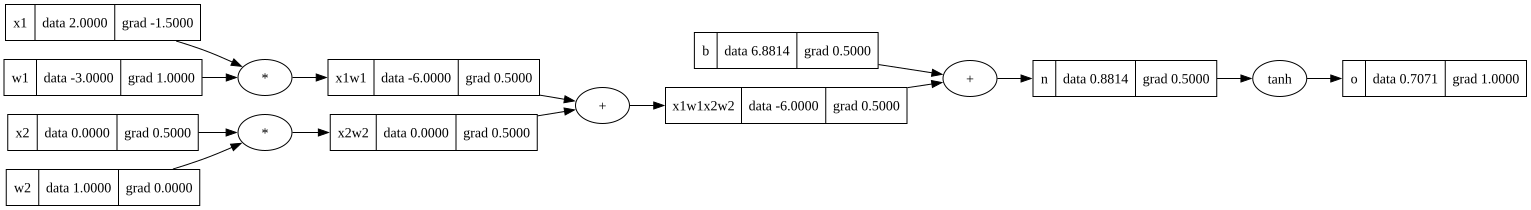

In [308]:
# inputs
x1 = Value(2.0, _label = "x1")
x2 = Value(0.0, _label = "x2")
# weights
w1 = Value(-3.0, _label = "w1")
w2 = Value(1.0, _label = "w2")
# bias of the neuron
b = Value(6.8813725870195432, _label = "b")
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1._label= "x1w1"
x2w2 = x2*w2; x2w2._label= "x2w2"
x1w1x2w2 = x1w1+x2w2; x1w1x2w2._label= "x1w1x2w2"
n = x1w1x2w2 + b; n._label = "n"
o = n.tanh(); o._label = "o"
o.backward()
draw_dot(o)

In [309]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for i in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self, x):
        # wx + b
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs 
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [472]:
xs = [
    [2.0, 3.0, -1.5],
    [3.0, -1.0 , 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] 
n = MLP(3,[4,4,1])
y_pred = [n(x) for x in xs]
y_pred

[Value(data=-0.695529991435531),
 Value(data=-0.5608422007357667),
 Value(data=-0.3610587512223924),
 Value(data=-0.7196902117002981)]

In [473]:
len(n.parameters())

41

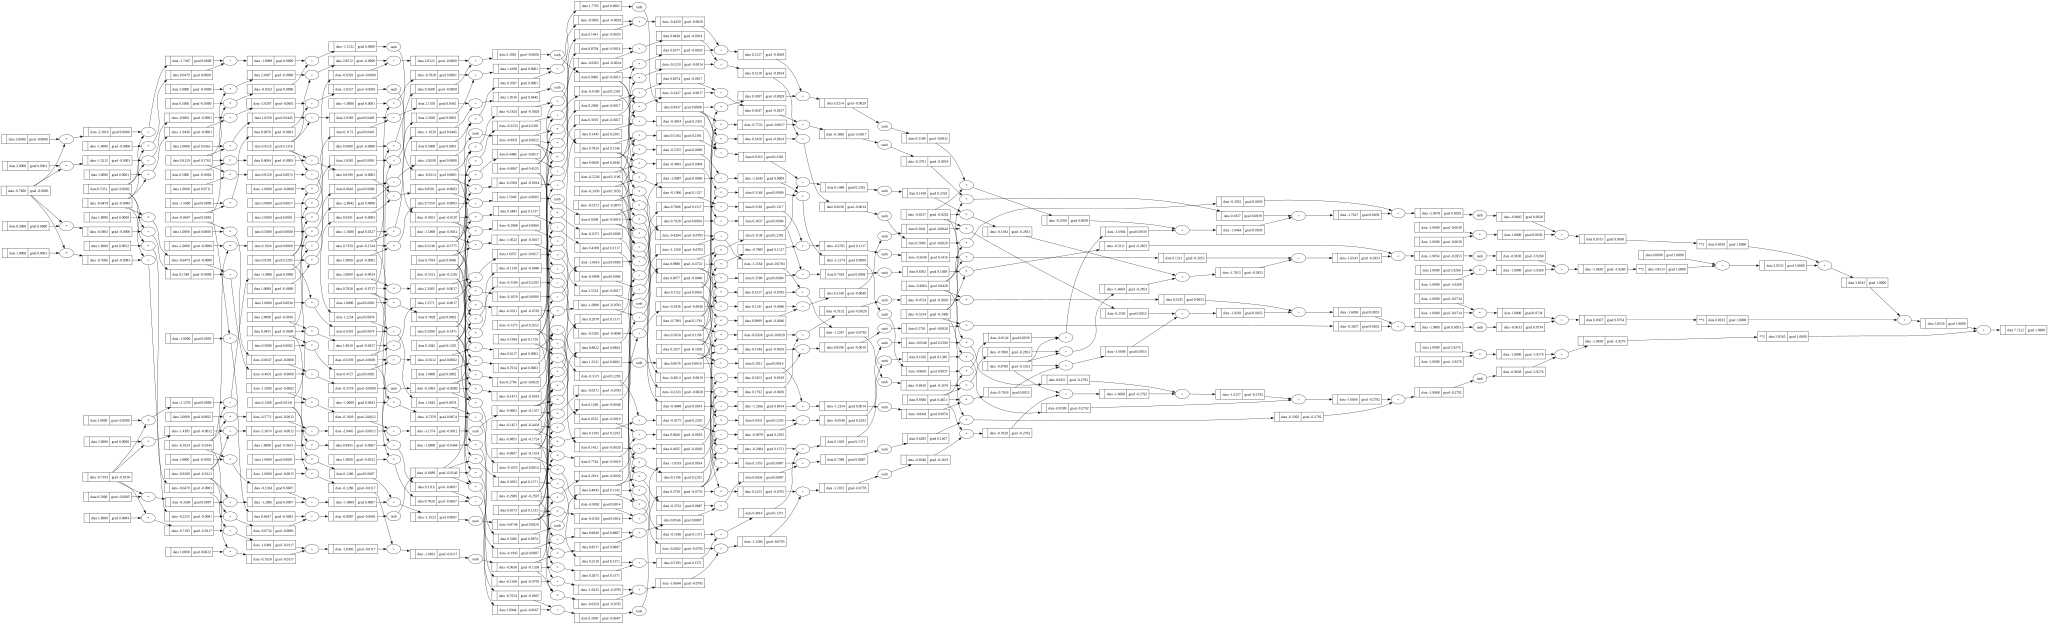

In [198]:
draw_dot(loss)

In [474]:
n.layers[0].neurons[0].w[0].grad

0.0

In [475]:
n.layers[0].neurons[0].w[0].data

0.3983182652819337

In [544]:
for i in range(100):
    # forward
    y_pred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys,y_pred)])
    # backward
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    # Gradient Descent
    for p in n.parameters():
        p.data += -0.01* p.grad
    print(i, loss.data)

0 0.0011567039821537804
1 0.0011562286911294822
2 0.0011557537811899589
3 0.0011552792518817905
4 0.0011548051027522464
5 0.0011543313333493323
6 0.0011538579432217432
7 0.0011533849319188935
8 0.0011529122989909144
9 0.0011524400439886342
10 0.001151968166463593
11 0.0011514966659680393
12 0.0011510255420549168
13 0.0011505547942778725
14 0.0011500844221912624
15 0.0011496144253501362
16 0.0011491448033102325
17 0.0011486755556280046
18 0.0011482066818605942
19 0.001147738181565835
20 0.0011472700543022551
21 0.0011468022996290743
22 0.0011463349171061952
23 0.0011458679062942205
24 0.0011454012667544318
25 0.0011449349980488012
26 0.0011444690997399892
27 0.0011440035713913234
28 0.001143538412566816
29 0.0011430736228312077
30 0.0011426092017498431
31 0.0011421451488887856
32 0.0011416814638147952
33 0.0011412181460952412
34 0.0011407551952982522
35 0.0011402926109925528
36 0.0011398303927475874
37 0.0011393685401334507
38 0.0011389070527209198
39 0.0011384459300814206
40 0.00113798

In [545]:
y_pred

[Value(data=0.985623108655449),
 Value(data=-0.990631302824736),
 Value(data=-0.9795889242763136),
 Value(data=0.9799912323618678)]

[Value(data=1.0662813329154202),
 Value(data=0.5770781938684562),
 Value(data=0.04047992678441213),
 Value(data=0.5980151441197683),
 Value(data=0.418165991378487),
 Value(data=-0.8434960230946125),
 Value(data=-1.2694881520269619),
 Value(data=0.7673635298189125),
 Value(data=0.026254569394995535),
 Value(data=0.6212410237427546),
 Value(data=-4.705932863012374),
 Value(data=-0.9268971314354248),
 Value(data=-1.3945766645903523),
 Value(data=2.1932387517149357),
 Value(data=-2.936078049673619),
 Value(data=0.4007478275384813),
 Value(data=0.4549423647409268),
 Value(data=0.8532809347310414),
 Value(data=2.4260981726802338),
 Value(data=1.7702460418957549),
 Value(data=-0.6149969642610231),
 Value(data=1.0499908259572133),
 Value(data=0.490197915376972),
 Value(data=1.639150278220383),
 Value(data=1.161316012278141),
 Value(data=-0.025369027569863166),
 Value(data=-1.2959606876320156),
 Value(data=-0.3960714123277801),
 Value(data=-1.6658616926839298),
 Value(data=-1.2583234579625955),

In [460]:
for p in n.parameters():
    print(p.data, p.grad)

0.6477242439632835 -3.0081149787046058
1.269504236618635 -1.8111047609053197
0.2997493771587728 2.9161465662889783
-0.20932593756941245 -0.6820672105973984
-0.8119200527855258 8.724129124279527
0.8207630182442083 -0.38810316000045614
-2.038453739039372 10.097624180353154
-1.6993405576035951 5.582159821992392
-1.3701403822430447 2.7182053594120856
-1.0064690756362498 0.9361738552122796
-0.2629064219057806 3.2475350998568446
-0.05333912810453293 2.3978627009181954
1.0237947853663674 -2.366883107699543
0.9702085537306954 -3.221739518114444
0.2608021483819296 2.6900799596370444
0.608241837282754 -1.6555974537163411
-0.06210959396933959 2.075382046993228
-1.0997740088014603 2.1949750287418857
0.150285989834466 -2.375651699625873
0.1609275966010113 2.7513442044364136
0.24023383691226277 2.5608108774513756
0.2586398712581566 3.370127004057636
2.9047955446539873 -14.571124120485363
-1.0755887719095178 4.803901194896321
-0.8002357812097762 7.060854977330276
-1.048536759089314 0.7160156594447622